Loaded shape: (512, 4096)


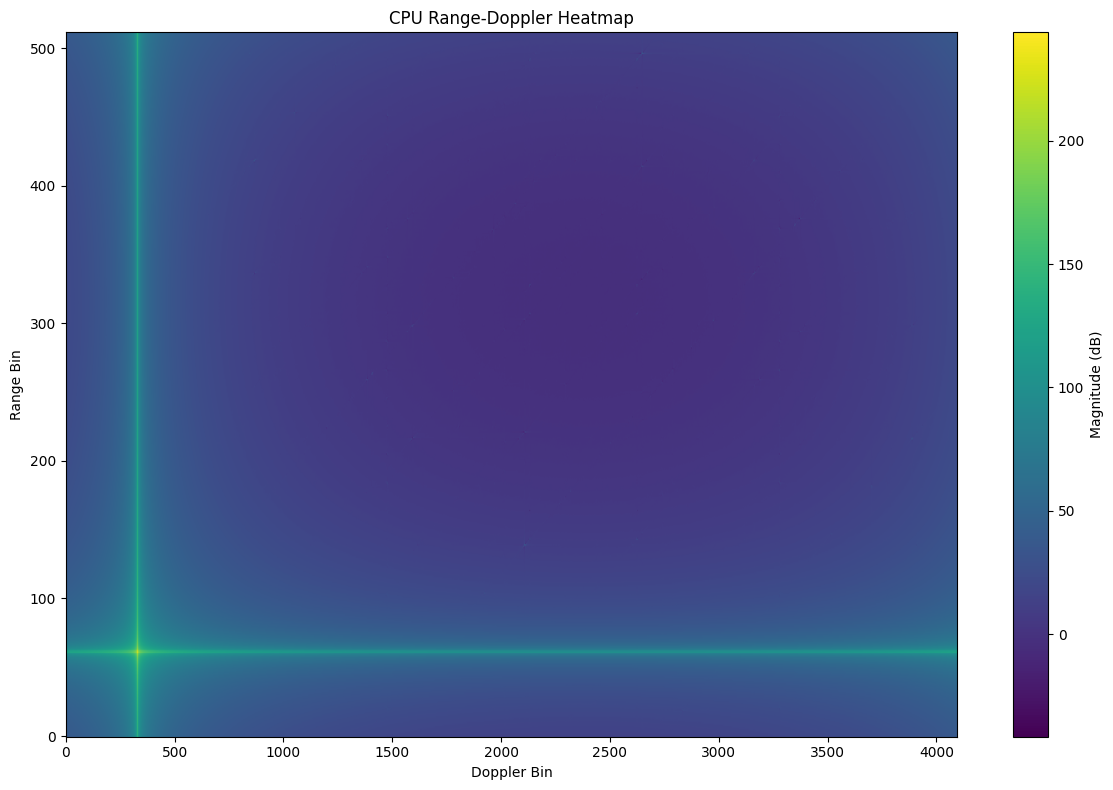

In [6]:
# Jupyter Notebook Cell
# Simple CPU Range-Doppler Workload Visualiser

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# -------------------------------------------------------------------
# CONFIG
# -------------------------------------------------------------------

csv_file = "cpu-data/range_doppler_map.csv"

# Set to True if your CSV contains headers
HAS_HEADER = False

# -------------------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------------------

if HAS_HEADER:
    data = pd.read_csv(csv_file)
    rd_map = data.values
else:
    rd_map = pd.read_csv(csv_file, header=None).values

print(f"Loaded shape: {rd_map.shape}")


# -------------------------------------------------------------------
# VISUALISE RANGE-DOPPLER MAP
# -------------------------------------------------------------------

plt.figure(figsize=(12, 8))

plt.imshow(
    20 * np.log10(np.abs(rd_map) + 1e-12),  # dB scale
    aspect='auto',
    origin='lower'
)

plt.colorbar(label='Magnitude (dB)')

plt.xlabel("Doppler Bin")
plt.ylabel("Range Bin")
plt.title("CPU Range-Doppler Heatmap")

plt.tight_layout()
plt.show()

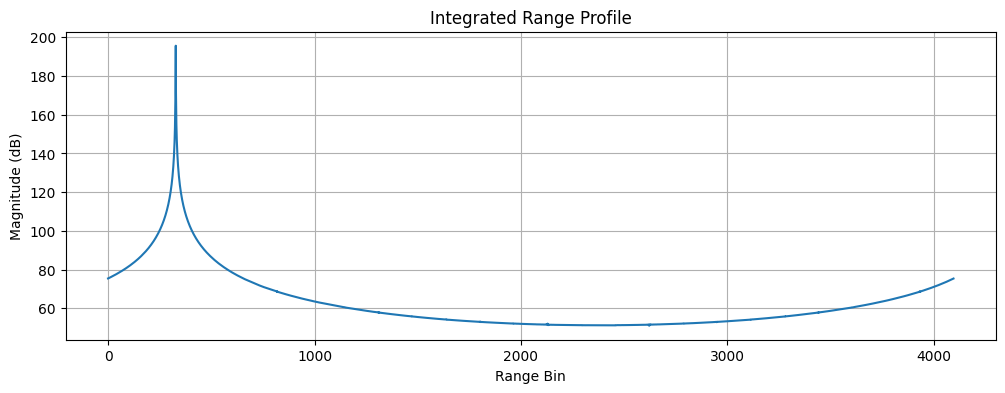

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rd_map = pd.read_csv(
    "cpu-data/range_doppler_map.csv",
    header=None
).values

range_profile = np.mean(rd_map, axis=0)

plt.figure(figsize=(12, 4))

plt.plot(
    20 * np.log10(range_profile + 1e-12)
)

plt.xlabel("Range Bin")
plt.ylabel("Magnitude (dB)")
plt.title("Integrated Range Profile")

plt.grid(True)
plt.show()

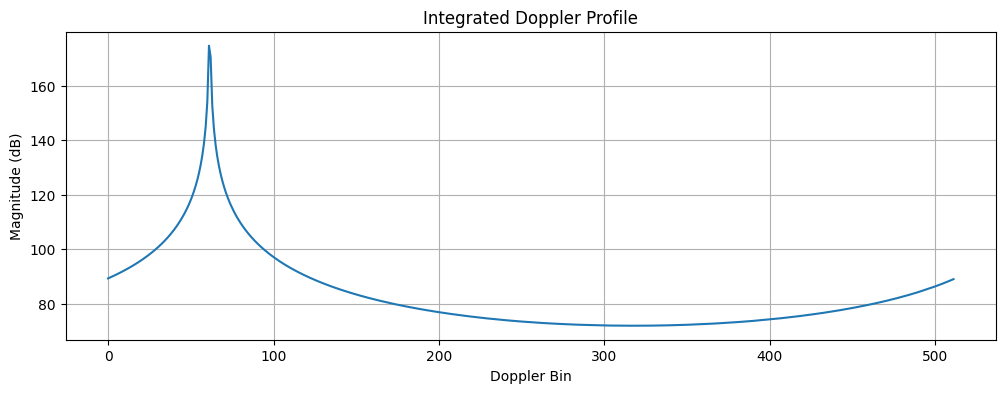

In [8]:
doppler_profile = np.mean(rd_map, axis=1)

plt.figure(figsize=(12, 4))

plt.plot(
    20 * np.log10(doppler_profile + 1e-12)
)

plt.xlabel("Doppler Bin")
plt.ylabel("Magnitude (dB)")
plt.title("Integrated Doppler Profile")

plt.grid(True)
plt.show()

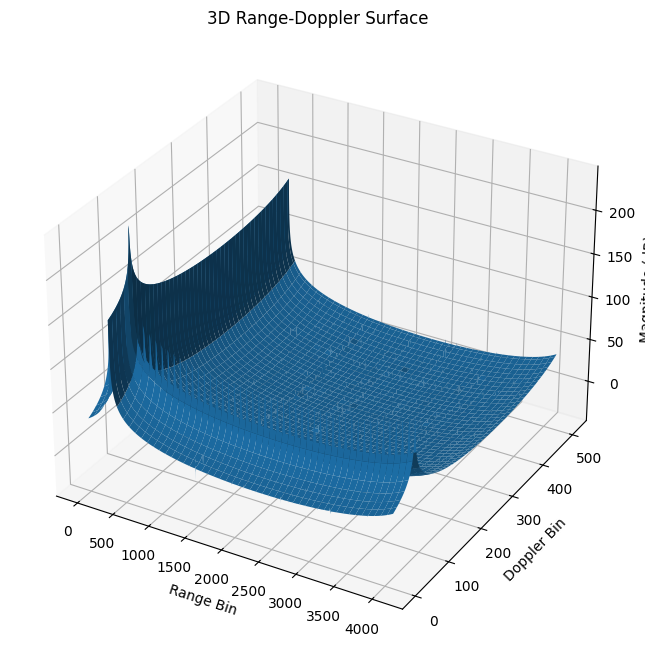

In [9]:
from mpl_toolkits.mplot3d import Axes3D

X, Y = np.meshgrid(
    np.arange(rd_map.shape[1]),
    np.arange(rd_map.shape[0])
)

Z = 20 * np.log10(rd_map + 1e-12)

fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, Z)

ax.set_xlabel("Range Bin")
ax.set_ylabel("Doppler Bin")
ax.set_zlabel("Magnitude (dB)")

plt.title("3D Range-Doppler Surface")
plt.show()

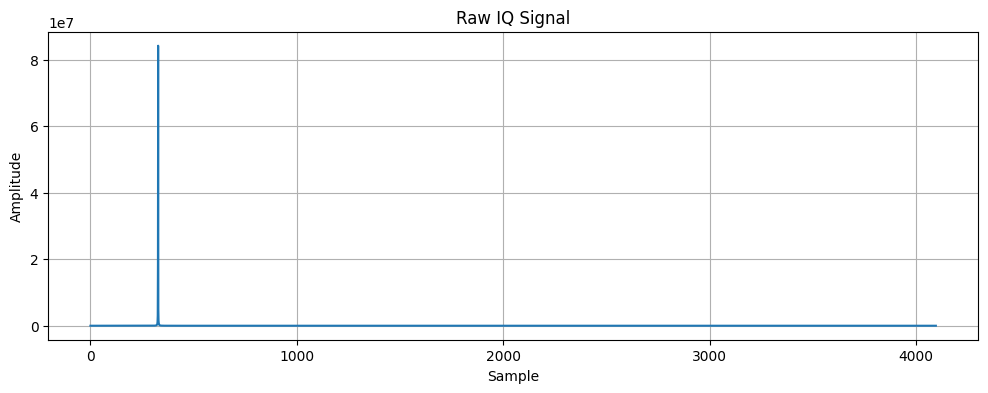

In [10]:
iq = rd_map[0]

plt.figure(figsize=(12, 4))

plt.plot(iq)

plt.title("Raw IQ Signal")
plt.xlabel("Sample")
plt.ylabel("Amplitude")

plt.grid(True)
plt.show()